# Стресс-тестирование риск-доходности продуктовой структуры розничного кредитного портфеля

### Сценарная модель границы экономически оправданного риска

Исследование оценивает, как состав синтетического розничного кредитного портфеля влияет на финансовый результат с учётом кредитного риска и величину кредитных потерь. Портфель включает ипотеку, потребительские кредиты, автокредиты и кредитные карты и откалиброван на публичных данных ВТБ и Банка России.

> **Цель — найти критические продуктовые доли там, где существует допустимое пересечение границы в сторону ухудшения результата (adverse crossing): дополнительный доход перестаёт компенсировать рост кредитных потерь. Наличие такого порога не предполагается заранее.**

## Исследовательский вопрос

**При какой доле более рискованных продуктов прирост дохода перестаёт компенсировать кредитные потери и снижение устойчивости портфеля к стрессу?**

Рабочая гипотеза: увеличение доли высокодоходных продуктов улучшает результат до некоторой границы; в стрессе эта граница может снижаться. Проверка строится на сценарном анализе, анализе чувствительности и обратном стресс-тестировании (reverse stress), а не на прогнозной регрессии.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "config" / "model_config.json").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import stress_model as sm

plt.style.use("seaborn-v0_8-whitegrid")
cfg = sm.load_config(ROOT / "config" / "model_config.json")
data = sm.load_dataset(ROOT / cfg.input_file, cfg.data_sheet)
base = sm.baseline_table(data, cfg)
product_results, sigmas = sm.build_scenarios(data, cfg)
summary = sm.scenario_summary(product_results, cfg.horizon_years)
factor = sm.factor_sensitivity(product_results, cfg)
reverse = sm.reverse_stress(product_results, cfg)
mortgage_sensitivity = sm.mortgage_pricing_sensitivity(data, cfg)
colors = {"Mortgage": "#4C78A8", "Consumer": "#F58518", "Auto": "#54A24B", "Cards": "#E45756"}

## Дизайн исследования

**Публичные данные и рыночные показатели-заменители → синтетический базовый портфель на 30.06.2026 → финансовый стресс → чувствительность к продуктовому составу → чувствительность к финансовым факторам → обратное стресс-тестирование → управленческая интерпретация**

| Категория | Элемент и роль в исследовании |
|---|---|
| FACT (опубликованный факт) | Экспозиции — объёмы кредитных требований — и компоненты ожидаемых кредитных убытков там, где источник проверен. Реконструированная и интерполированная история остаётся вспомогательной. |
| MARKET PROXY (рыночный показатель-заменитель) | Внешние ставки Банка России по кредитам и фондированию, а не внутренняя доходность продуктов ВТБ. |
| SYNTHETIC (синтетическая конструкция) | Сочетание публичных экспозиций с внешними ставками в модельный четырёхпродуктовый портфель. |
| MODEL ASSUMPTION (модельная предпосылка) | Стрессовые множители и сдвиги продуктовых долей. |
| CALCULATED (расчётная величина) | Стоимость кредитного риска, спред, шестимесячный финансовый результат и допустимые пороги. |

Базовая дата — **30.06.2026**, горизонт — **второе полугодие 2026 года (2026H2), 0,5 года**. Общая экспозиция равна сумме четырёх продуктов и сохраняется при изменении долей.

## Модель финансового результата

Стоимость кредитного риска (credit cost) рассчитывается по переоценке ожидаемых кредитных убытков ECL (expected credit losses) за полугодие и средней экспозиции, с приведением к годовому выражению:

$$CreditCost_i=\frac{2\times ECL\ remeasurement_i}{(Exposure_{i,t-1}+Exposure_{i,t})/2}$$

CRAS (credit-risk-adjusted spread — спред с учётом кредитного риска):

$$CRAS_i=Pricing_i-Funding_i-CreditCost_i$$

RAFR (risk-adjusted financial result — финансовый результат с учётом кредитного риска) за шесть месяцев:

$$RAFR_{6M}=0.5\times\sum_i Exposure_i\times CRAS_i$$

RAFR — результат до операционных расходов (pre-operating result). Он не включает комиссии, операционные расходы, налоги и стоимость капитала. Он не является фактической прибылью ВТБ, NIM (net interest margin — чистой процентной маржой), внутренней продуктовой маржой или RAROC (risk-adjusted return on capital — доходностью капитала с учётом риска). В формулах Pricing (ставка по кредиту), Funding (стоимость фондирования), Exposure (экспозиция), CreditCost (стоимость кредитного риска), ECL remeasurement (переоценка ожидаемых кредитных убытков).

## Термины и сокращения

| Термин | Расшифровка и смысл |
|---|---|
| CRAS | Credit-risk-adjusted spread — спред с учётом кредитного риска: ставка по кредиту минус фондирование и стоимость кредитного риска, в годовом выражении. |
| RAFR | Risk-adjusted financial result — финансовый результат с учётом кредитного риска; в модели рассчитывается за шесть месяцев. |
| ECL | Expected credit losses — ожидаемые кредитные убытки; резерв отражает запас на дату, переоценка — компонент расчёта стоимости риска за период. |
| CoR | Cost of risk — стоимость риска; официальный показатель группы отличается по охвату и определению от продуктового исследовательского показателя. |
| NIM | Net interest margin — чистая процентная маржа. |
| FTP | Funds transfer pricing — внутреннее трансфертное ценообразование на фондирование. |
| RAROC | Risk-adjusted return on capital — доходность капитала с учётом риска. |
| RWA | Risk-weighted assets — активы, взвешенные по риску. |
| Opex | Operating expenses — операционные расходы. |
| LGD | Loss given default — доля потерь при дефолте. |
| NA | Not available — порог не представлен; причину указывает статус расчёта. |
| H1 / H2 / 6M | First half / second half / six months — первое полугодие / второе полугодие / шесть месяцев. |
| Exposure | Кредитная экспозиция: объём требований по продукту, используемый в модели. |
| Pricing / funding | Ставка по кредиту / стоимость фондирования. |
| Market proxy | Рыночный показатель-заменитель: внешняя ставка вместо ненаблюдаемой внутренней ставки банка. |
| Baseline / Base Mix | Базовый вариант / исходный продуктовый состав. |
| Base / Moderate / Severe | Базовый / умеренный / тяжёлый финансовый сценарий. |
| Portfolio-mix sensitivity (PortfolioMix) | Чувствительность к продуктовому составу при неизменной общей экспозиции. |
| Severe + Portfolio Mix (SevereMix) | Тяжёлые финансовые предпосылки в сочетании с изменением продуктового состава. |
| Reverse stress / adverse crossing | Обратное стресс-тестирование / пересечение критической границы в сторону ухудшения результата. |
| Break-even | Безубыточность: значение параметра, при котором соответствующий результат равен нулю. |
| QA / ML | Quality assurance / machine learning — проверка качества / машинное обучение. |
| п.п. / bp | Процентный пункт / basis point (базисный пункт); 100 базисных пунктов равны одному процентному пункту. |

## Базовая структура портфеля

Базовый вариант (baseline) сочетает публичные ориентиры экспозиции и внешние рыночные ставки. Таблица показывает вклад каждого продукта в риск-доходность портфеля.

In [2]:
base_results = sm.calculate_product_results(base, cfg.horizon_years, "Base")
baseline_view = base_results[[
    "product", "exposure", "weight", "credit_cost", "product_rate",
    "funding_rate", "credit_risk_adjusted_spread", "risk_adjusted_financial_result_bn"
]].copy()
baseline_view["product"] = baseline_view["product"].map(sm.PRODUCT_LABELS)
baseline_view.columns = ["Продукт", "Объём, млрд руб.", "Доля", "Стоимость риска", "Ставка по кредиту", "Фондирование", "Спред CRAS", "Результат RAFR за 6 месяцев, млрд руб."]
display(baseline_view.style.hide(axis="index").format({
    "Объём, млрд руб.": "{:,.1f}", "Доля": "{:.1%}", "Стоимость риска": "{:.2%}",
    "Ставка по кредиту": "{:.2%}", "Фондирование": "{:.2%}", "Спред CRAS": "{:.2%}",
    "Результат RAFR за 6 месяцев, млрд руб.": "{:,.1f}"
}))
portfolio_result = float(base_results.risk_adjusted_financial_result_bn.sum())
display(Markdown(
    f"**Размер портфеля:** {base.exposure.sum():,.1f} млрд руб.  "
    f"**Базовый спред CRAS:** {portfolio_result / base.exposure.sum() / cfg.horizon_years:.2%}.  "
    f"**Базовый результат RAFR за 6 месяцев:** {portfolio_result:,.1f} млрд руб."
))

Продукт,"Объём, млрд руб.",Доля,Стоимость риска,Ставка по кредиту,Фондирование,Спред CRAS,"Результат RAFR за 6 месяцев, млрд руб."
Автокредиты,543.9,8.3%,4.35%,16.50%,10.90%,1.25%,3.4
Кредитные карты,223.4,3.4%,5.59%,31.20%,13.00%,12.61%,14.1
Потребительские кредиты,"1,525.9",23.2%,4.25%,17.50%,10.90%,2.35%,17.9
Ипотека,"4,279.8",65.1%,0.68%,9.00%,10.90%,-2.58%,-55.2


**Размер портфеля:** 6,573.0 млрд руб.  **Базовый спред CRAS:** -0.60%.  **Базовый результат RAFR за 6 месяцев:** -19.8 млрд руб.

## Риск и доходность продуктов

Положение относительно диагонали показывает, компенсирует ли спред до учёта кредитного риска текущую стоимость кредитного риска (credit cost). Размер точки пропорционален экспозиции (exposure — объёму кредитных требований).

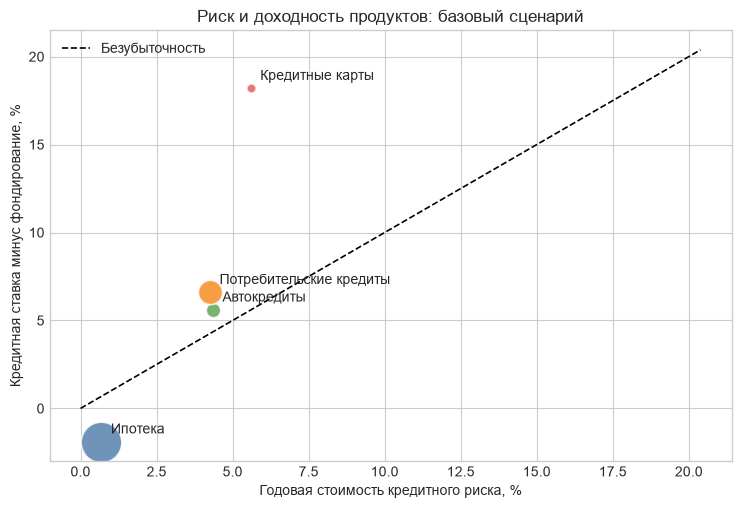

In [3]:
plot_base = base_results.copy()
plot_base["pre_risk_spread"] = plot_base.product_rate - plot_base.funding_rate
limit = max(plot_base.credit_cost.max(), plot_base.pre_risk_spread.max()) * 1.12

fig, ax = plt.subplots(figsize=(8.8, 5.6))
ax.plot([0, limit * 100], [0, limit * 100], linestyle="--", color="black", linewidth=1.2, label="Безубыточность")
for _, row in plot_base.iterrows():
    ax.scatter(row.credit_cost * 100, row.pre_risk_spread * 100,
               s=row.exposure / 5, color=colors[row['product']], alpha=0.8, edgecolor="white", linewidth=1.2)
    ax.annotate(sm.PRODUCT_LABELS[row["product"]], (row.credit_cost * 100, row.pre_risk_spread * 100),
                xytext=(7, 6), textcoords="offset points", fontsize=10)
ax.set_xlabel("Годовая стоимость кредитного риска, %")
ax.set_ylabel("Кредитная ставка минус фондирование, %")
ax.set_title("Риск и доходность продуктов: базовый сценарий")
ax.legend()
plt.show()

## Финансовый стресс и эксперименты с продуктовой структурой

**Финансовые сценарии** сохраняют исходный продуктовый состав:

- **Базовый (Base):** исходные финансовые предпосылки.
- **Умеренный (Moderate):** умеренное ухудшение стоимости риска, кредитных ставок и фондирования.
- **Тяжёлый (Severe):** более сильное одновременное ухудшение финансовых факторов.

**Эксперименты с продуктовым составом** сохраняют общую экспозицию:

- **Исходный состав (Base Mix):** неизменные базовые доли.
- **Чувствительность к продуктовому составу (Portfolio-mix sensitivity, PortfolioMix):** перенос долей из ипотеки в другие продукты при базовых финансовых предпосылках; используется настроенный умеренный сдвиг.
- **Тяжёлый сценарий с изменением состава (Severe + Portfolio Mix, SevereMix):** тяжёлые финансовые предпосылки плюс настроенный тяжёлый сдвиг долей.

Коэффициенты и сдвиги являются модельными предпосылками, а не статистически оценённым прогнозом.

Сценарий,"Кредитные потери, млрд руб.",Спред CRAS,"Результат RAFR за 6 месяцев, млрд руб."
Базовый,65.1,-0.60%,-19.8
Умеренный,73.6,-2.15%,-70.6
Тяжёлый,82.1,-3.70%,-121.5
Изменение состава,69.4,-0.39%,-12.8
Тяжёлый + изменение состава,93.6,-3.42%,-112.3


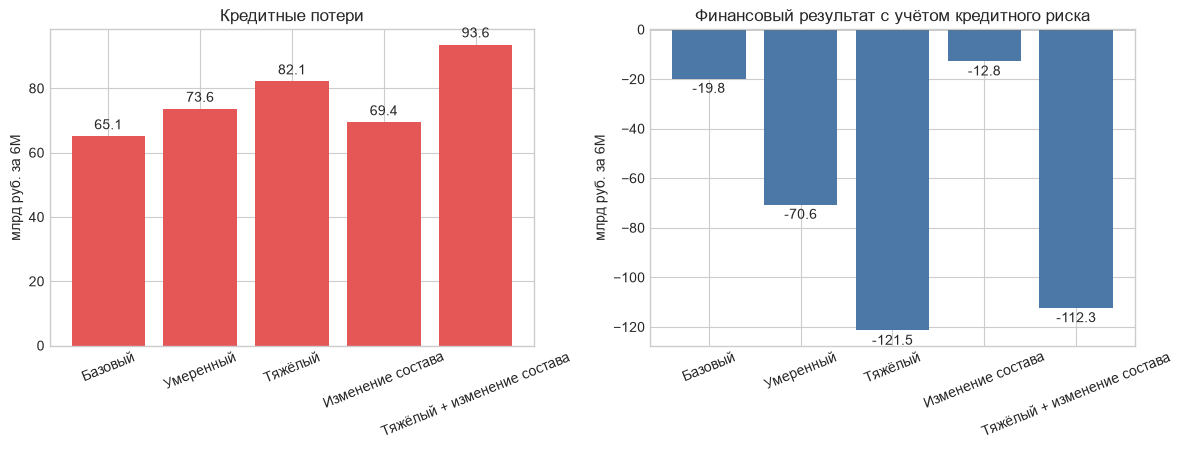

In [4]:
scenario_view = summary[["scenario", "credit_loss_bn", "credit_risk_adjusted_spread", "risk_adjusted_financial_result_bn"]].copy()
scenario_view["scenario"] = scenario_view.scenario.map(sm.scenario_label)
scenario_view.columns = ["Сценарий", "Кредитные потери, млрд руб.", "Спред CRAS", "Результат RAFR за 6 месяцев, млрд руб."]
display(scenario_view.style.hide(axis="index").format({
    "Кредитные потери, млрд руб.": "{:,.1f}", "Спред CRAS": "{:.2%}", "Результат RAFR за 6 месяцев, млрд руб.": "{:,.1f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
bars_1 = axes[0].bar(summary.scenario.map(sm.scenario_label), summary.credit_loss_bn, color="#E45756")
axes[0].bar_label(bars_1, fmt="%.1f", padding=3)
axes[0].set_title("Кредитные потери")
axes[0].set_ylabel("млрд руб. за 6М")
axes[0].tick_params(axis="x", rotation=22)

bars_2 = axes[1].bar(summary.scenario.map(sm.scenario_label), summary.risk_adjusted_financial_result_bn, color="#4C78A8")
axes[1].bar_label(bars_2, fmt="%.1f", padding=3)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Финансовый результат с учётом кредитного риска")
axes[1].set_ylabel("млрд руб. за 6М")
axes[1].tick_params(axis="x", rotation=22)
fig.tight_layout()
plt.show()

## Чувствительность к продуктовому составу

Как изменится шестимесячный результат, если один процентный пункт (п.п.) портфеля перенести из ипотеки в другой продукт при сохранении общего объёма?

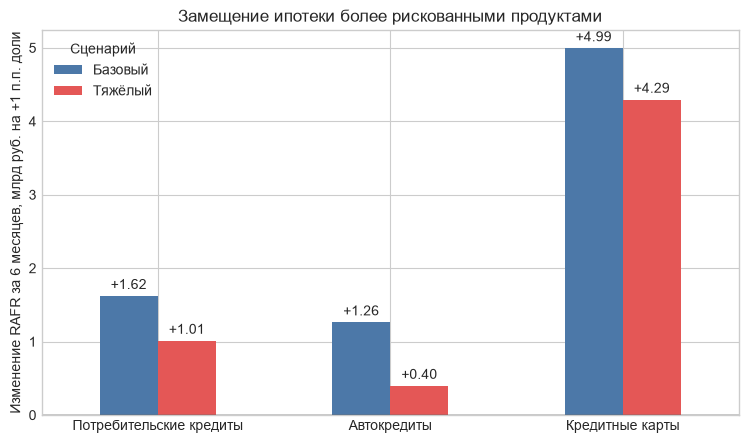

scenario,Базовый,Тяжёлый
product,,
Потребительские кредиты,+1.62,+1.01
Автокредиты,+1.26,+0.40
Кредитные карты,+4.99,+4.29


In [5]:
share_effect = factor[
    factor.factor.eq("share_plus_1pp_vs_mortgage") & factor.scenario.isin(["Base", "Severe"])
].pivot(index="product", columns="scenario", values="delta_result_bn").reindex(sm.RISKIER_PRODUCTS)

ax = share_effect.rename(index=sm.PRODUCT_LABELS, columns=sm.scenario_label).plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Изменение RAFR за 6 месяцев, млрд руб. на +1 п.п. доли")
ax.set_title("Замещение ипотеки более рискованными продуктами")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Сценарий")
for container in ax.containers:
    ax.bar_label(container, fmt="%+.2f", padding=3)
plt.show()
display(share_effect.rename(index=sm.PRODUCT_LABELS, columns=sm.scenario_label).style.format("{:+.2f}"))

## Найдена ли критическая продуктовая доля?

При текущих показателях-заменителях потребительские кредиты, автокредиты и кредитные карты имеют более высокий спред с учётом кредитного риска, чем ипотека. Увеличение их долей **улучшает**, а не ухудшает модельный результат даже в тяжёлом сценарии. Одновременно исходный финансовый результат уже ниже нулевой границы.

Пересечение границы в сторону ухудшения из исходной точки отсутствует. Обратное стресс-тестирование возвращает **NA (not available — порог не представлен)** с поясняющим статусом, а не искусственную критическую долю.

Это не означает, что более рискованный состав всегда выгоднее: искомая граница не выявляется при текущем сочетании внешних ставок и стоимости риска.

Статус `ALREADY_AT_OR_BELOW_BOUNDARY` (исходный результат уже на критической границе или ниже) сопровождает NA для продуктовых долей. `THRESHOLD_BELOW_CURRENT_1X` (граница требует множителя стоимости риска ниже текущего 1) означает снижение стоимости риска для достижения нуля; это не порог ухудшения.

In [6]:
base_reverse = reverse[reverse.scenario.eq("Base")]
portfolio_threshold = base_reverse[base_reverse.reverse_type.eq("portfolio_credit_cost_multiplier")].iloc[0]
break_even = base_reverse[base_reverse.reverse_type.eq("product_break_even_credit_cost")].set_index("target_product")
share_rows = base_reverse[base_reverse.reverse_type.eq("critical_product_share_vs_mortgage")].set_index("target_product")

threshold_view = pd.DataFrame({
    "Показатель": [
        "Множитель стоимости риска портфеля до RAFR = 0",
        "Критическая доля потребительских кредитов", "Критическая доля автокредитов", "Критическая доля кредитных карт",
        "Безубыточная стоимость риска: потребительские кредиты", "Безубыточная стоимость риска: автокредиты", "Безубыточная стоимость риска: кредитные карты"
    ],
    "Значение": [
        f"{portfolio_threshold.threshold:.3f}x",
        "NA", "NA", "NA",
        f"{break_even.loc['Consumer', 'threshold']:.2%}",
        f"{break_even.loc['Auto', 'threshold']:.2%}",
        f"{break_even.loc['Cards', 'threshold']:.2%}"
    ],
    "Интерпретация": [
        "Нулевая граница требует снижения текущей стоимости риска",
        share_rows.loc["Consumer", "status"], share_rows.loc["Auto", "status"], share_rows.loc["Cards", "status"],
        "Годовая стоимость риска при нулевом продуктовом спреде",
        "Годовая стоимость риска при нулевом продуктовом спреде",
        "Годовая стоимость риска при нулевом продуктовом спреде"
    ]
})
threshold_view["Интерпретация"] = threshold_view["Интерпретация"].replace(sm.STATUS_LABELS)
display(threshold_view.style.hide(axis="index"))

Показатель,Значение,Интерпретация
Множитель стоимости риска портфеля до RAFR = 0,0.696x,Нулевая граница требует снижения текущей стоимости риска
Критическая доля потребительских кредитов,NA,Исходный результат уже на критической границе или ниже
Критическая доля автокредитов,NA,Исходный результат уже на критической границе или ниже
Критическая доля кредитных карт,NA,Исходный результат уже на критической границе или ниже
Безубыточная стоимость риска: потребительские кредиты,6.60%,Годовая стоимость риска при нулевом продуктовом спреде
Безубыточная стоимость риска: автокредиты,5.60%,Годовая стоимость риска при нулевом продуктовом спреде
Безубыточная стоимость риска: кредитные карты,18.20%,Годовая стоимость риска при нулевом продуктовом спреде


## Ключевая чувствительность: ипотечная ставка

В базовом сценарии ипотечная ставка-заменитель (mortgage pricing proxy) равна 9,0%. Рыночная ставка 17,8% используется только как крайняя точка анализа чувствительности (sensitivity endpoint) и не оценивает фактическую доходность ипотечного портфеля ВТБ.

Анализ показывает зависимость выводов о границе риска от экономической сопоставимости доходной части модели.

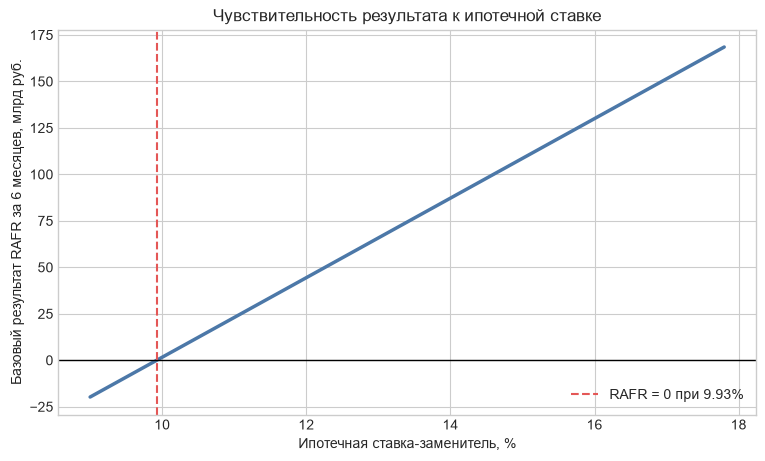

При неизменных остальных параметрах нулевая граница базового сценария достигается при ипотечной ставке около **9.93%**. При крайней ставке 17,8% финансовый результат RAFR составляет **168.5 млрд руб.**

In [7]:
mortgage_row = base_results[base_results['product'].eq('Mortgage')].iloc[0]
critical_mortgage_rate = mortgage_row.product_rate + (cfg.critical_result_bn - portfolio_result) / (mortgage_row.exposure * cfg.horizon_years)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mortgage_sensitivity.mortgage_pricing_rate * 100,
        mortgage_sensitivity.risk_adjusted_financial_result_bn, color="#4C78A8", linewidth=2.5)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(critical_mortgage_rate * 100, color="#E45756", linestyle="--",
           label=f"RAFR = 0 при {critical_mortgage_rate:.2%}")
ax.set_xlabel("Ипотечная ставка-заменитель, %")
ax.set_ylabel("Базовый результат RAFR за 6 месяцев, млрд руб.")
ax.set_title("Чувствительность результата к ипотечной ставке")
ax.legend()
plt.show()
display(Markdown(
    f"При неизменных остальных параметрах нулевая граница базового сценария достигается при ипотечной ставке около "
    f"**{critical_mortgage_rate:.2%}**. При крайней ставке 17,8% финансовый результат RAFR составляет "
    f"**{mortgage_sensitivity.iloc[-1].risk_adjusted_financial_result_bn:,.1f} млрд руб.**"
))

## Предварительные научные выводы

1. Продуктовый состав существенно влияет на модельный финансовый результат: эффект перераспределения одного процентного пункта различается по продуктам и сценариям.
2. Финансовый стресс последовательно повышает кредитные потери и снижает финансовый результат, но точные уровни умеренного и тяжёлого сценариев зависят от рабочих коэффициентов.
3. При текущей калибровке гипотеза о критической доле более рискованных продуктов **не подтверждается**: замещение ипотеки улучшает результат, а исходный портфель уже ниже критической границы.
4. Главная причина неустойчивости вывода — ипотечная ставка-заменитель. Её изменение способно поменять величину и знак результата и направление чувствительности к составу.
5. Итоговый порог экономически оправданного риска следует публиковать после проверки сопоставимости доходных показателей и устойчивости результата в альтернативных калибровках.

> **Текущий результат — количественная диагностика условий для обоснованной рекомендации, а не готовая рекомендация по структуре портфеля ВТБ.**

### Управленческая интерпретация и ограничения

Автоматический выбор лучшего портфеля, оптимизация доли потерь при дефолте, распределение капитала, учёт активов, взвешенных по риску, моделирование Монте-Карло, регрессия и машинное обучение не входят в текущий этап. Последующая система принятия решений требует экспертной фиксации доходной части модели и финансовых стресс-сценариев. Короткая история и изменение периметра при интеграции Почта Банка ограничивают историческую интерпретацию.